# DPC and qDPC Imaging with the openUC2 Seeed Studio Microscope

## Goals

In this notebook, you will:

- Connect the openUC2 Seeed Studio Microscope as a USB webcam
- Control the LED matrix to vary illumination patterns (left, right, top, bottom, ring)
- Acquire images under different directional illuminations
- Calculate a Differential Phase Contrast (DPC) image
- Optionally reconstruct a Quantitative DPC (qDPC) phase map

## Background

Biological samples, especially unstained cells, often exhibit low contrast under brightfield illumination. By controlling the angle of illumination, we can highlight phase gradients—changes in optical density—which are otherwise invisible.

Differential Phase Contrast (DPC) uses asymmetric illumination to estimate local phase gradients. This enhances image contrast and reveals subcellular structures. The basic mathematicall formular is the following: `(I_top-I_bottom)/(I_top+I_bottom)`. This subtracts the brigthfield image from the gradient image. 

Quantitative DPC (qDPC) goes one step further by reconstructing the actual phase distribution of the sample—providing information about refractive index variations or thickness. This is done by computing the (weak) object transfer function and then further deconvolves the images with the resutling response function 

*Further reading:*
- Introduction to Digital Microscopy: https://openuc2.github.io/docs/Toolboxes/DiscoveryElectronics/DigitalMicroscopy
- Theory and Implementation of DPC: https://openuc2.github.io/docs/Toolboxes/DiscoveryPhaseMicroscopy/DPCmicroscopy/

## Prerequisites

Install the following Python libraries before running the notebook:

```bash
pip install https://github.com/openUC2/UC2-REST/archive/refs/heads/master.zip
pip install imageio[ffmpeg]
pip install numpy scipy matplotlib


# Getting to know the LED Array

In [10]:
#%%
import uc2rest
import numpy as np
import time

# Connect the LED array to the computer and try to find it 
port = "unknown"
ESP32 = uc2rest.UC2Client(serialport=port, baudrate=115200, DEBUG=False)

# Create LedMatrix object, pass a reference to your “parent” that has post_json()
my_led_matrix = ESP32.led


# Flash it a few times
for i in range(2):
    # Turn off all LEDs
    my_led_matrix.send_LEDMatrix_off()
    time.sleep(0.1)
    # Fill entire matrix with red
    my_led_matrix.send_LEDMatrix_full((255,0,0), getReturn=False)
    time.sleep(0.1)

# Light only left half in bright white
mDirections = ["left", "right", "top", "bottom"]
for iDirection in mDirections:
    my_led_matrix.send_LEDMatrix_halves(region=iDirection, intensity=(255,255,255), getReturn=False)
    time.sleep(0.1)
    mFrames.append(cam.read()[-1])

# Draw a ring of radius 3 in purple
my_led_matrix.send_LEDMatrix_rings(radius=3, intensity=(128,0,128))

# Draw a filled circle of radius 5 in green
my_led_matrix.send_LEDMatrix_circles(radius=3, intensity=(0,255,0))

# turn on indidivual LEDs
for iLED in range(5):
    # timeout = 0 means no timeout => mResult will be rubish!
    mResult = ESP32.led.send_LEDMatrix_single(indexled=iLED, intensity=(255, 255, 255), getReturn=0, timeout=0.1)
    mResult = ESP32.led.send_LEDMatrix_single(indexled=iLED, intensity=(0, 0, 0),  getReturn=0, timeout=0.1)

# display random pattern
for i in range(5):
    led_pattern = np.random.randint(0,55, (25,3))
    mResult = ESP32.led.send_LEDMatrix_array(led_pattern=led_pattern,getReturn=0,timeout=0)

# turn off
ESP32.led.send_LEDMatrix_full(intensity=(0, 0, 0), getReturn=False)


[OpenDevice]: Port not found
Using API version 2
{0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}
[SendingCommands]:{"task": "/ledarr_act", "qid": 1, "led": {"action": "off"}}

[ProcessLines]:[ 17466][I][LedController.cpp:351] parseLedCommand(): ParseLedCommand: action: off
[ProcessLines]:++
[ProcessLines]:{"qid":1,"success":1}
[ProcessLines]:--
[ProcessCommands]: {'qid': 1, 'success': 1}
[SendingCommands]:{"task": "/ledarr_act", "qid": 2, "led": {"action": "fill", "LEDArrMode": 1, "r": 255, "g": 0, "b": 0}}

[ProcessLines]:[ 17734][I][LedController.cpp:341] parseLedCommand(): parseLedCommand: LEDArrMode: 1
[ProcessLines]:[ 17742][I][LedController.cpp:351] parseLedCommand(): ParseLedCommand: action: fill
[ProcessLines]:++
[ProcessLines]:{"qid":2,"success":1}
[ProcessLines]:--
[ProcessCommands]: {'qid': 2, 'success': 1}
[SendingCommands]:{"task": "/ledarr_act", "qid": 3, "led": {"action": "halves", "region": "left", "r": 255, "g": 255, "b": 255}}

[ProcessLines]:[ 

# Getting to know the camera

In [ ]:
import imageio as iio
import matplotlib.pyplot as plt
import numpy as np
import time

# initialize camera
camera = iio.get_reader("<video0>")

# acquire some frames
for i in range(10):
    mFrame = camera.get_next_data()
    time.sleep(0.1)
    plt.imshow(mFrame), plt.show()

# close camera
camera.close()


# Acquiring the images at varying illumination and merge them 

Using API version 2
{0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}
[SendingCommands]:{"task": "/ledarr_act", "qid": 1, "led": {"action": "halves", "region": "left", "r": 0, "g": 0, "b": 255}}

[ProcessLines]:+
[ProcessLines]:{qid1"ucs"1-


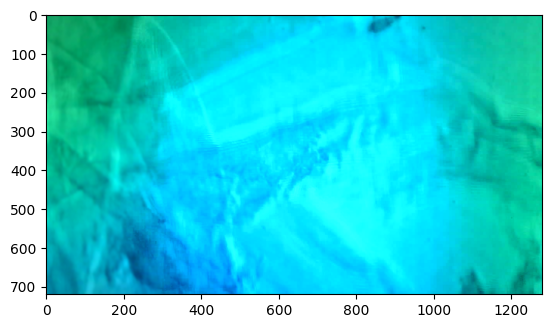

[SendingCommands]:{"task": "/ledarr_act", "qid": 2, "led": {"action": "halves", "region": "right", "r": 0, "g": 0, "b": 255}}

[ProcessLines]:++
Failed to read the line in serial: device reports readiness to read but returned no data (device disconnected or multiple access on port?)
Failed to read the line in serial: 'bool' object has no attribute 'decode'
Failed to read the line in serial: device reports readiness to read but returned no data (device disconnected or multiple access on port?)
Failed to read the line in serial: 'bool' object has no attribute 'decode'
Failed to load the json from serial 
Error: Expecting value: line 1 column 1 (char 0)


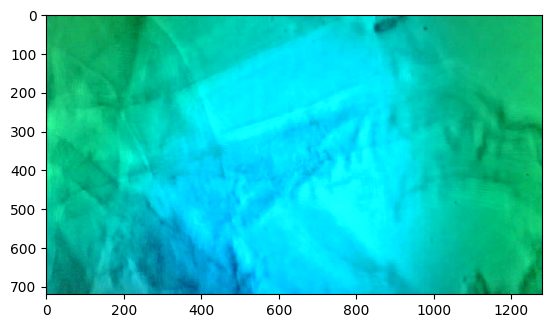

[SendingCommands]:{"task": "/ledarr_act", "qid": 3, "led": {"action": "halves", "region": "top", "r": 0, "g": 0, "b": 255}}

[ProcessLines]:+
Failed to read the line in serial: device reports readiness to read but returned no data (device disconnected or multiple access on port?)
Failed to read the line in serial: 'bool' object has no attribute 'decode'
Reconnecting to the serial device
Reconnected to the serial device


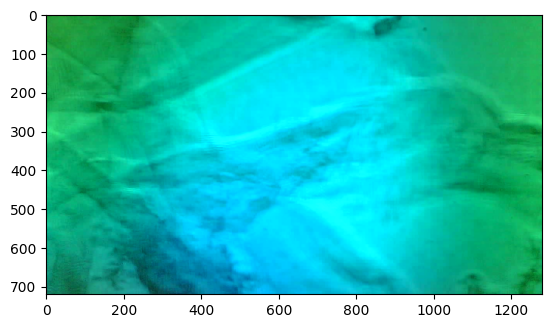

[SendingCommands]:{"task": "/ledarr_act", "qid": 1, "led": {"action": "halves", "region": "bottom", "r": 0, "g": 0, "b": 255}}

Failed to read the line in serial: device reports readiness to read but returned no data (device disconnected or multiple access on port?)
Failed to read the line in serial: 'bool' object has no attribute 'decode'
[ProcessLines]:{"qid":1,"success":1}
[ProcessLines]:--
Failed to load the json from serial 
Error: Expecting value: line 1 column 1 (char 0)
[ProcessLines]:+{"state":r"deifr_":2.,"en_4 0592:2,ietfe_,"conf":0,"pindef":"waveshare_esp32s3_ledarray","I2C_SLAVE":0},"qid":0}
[ProcessLines]:--
Failed to load the json from serial 
Error: Expecting value: line 1 column 1 (char 0)


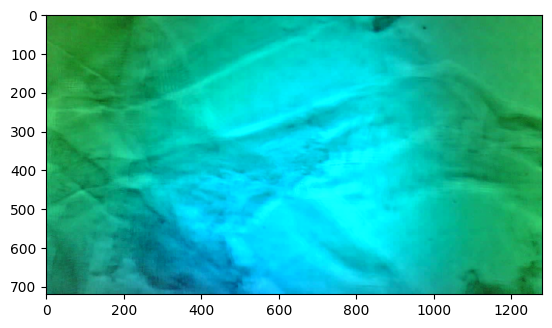

[SendingCommands]:{"task": "/ledarr_act", "qid": 2, "led": {"action": "off"}}

[ProcessLines]:++
[ProcessLines]:{"qid":2,"success":1}
[ProcessLines]:--
Failed to load the json from serial 
Error: Expecting value: line 1 column 1 (char 0)
It takes too long to get a response, we will resend the last command: {'task': '/ledarr_act', 'qid': 2, 'led': {'action': 'off'}}
Failed to write the line in serial: We have a queue, so after a while we need to resend the wrong command!
It takes too long to get a response, we will resend the last command: {'task': '/ledarr_act', 'qid': 2, 'led': {'action': 'off'}}
Failed to write the line in serial: We have a queue, so after a while we need to resend the wrong command!
It takes too long to get a response, we will resend the last command: {'task': '/ledarr_act', 'qid': 2, 'led': {'action': 'off'}}
Failed to write the line in serial: We have a queue, so after a while we need to resend the wrong command!
It takes too long to get a response, we will resend

'No response received'

[ProcessCommands]: {'qid': 2, 'success': 1}


In [7]:
import imageio as iio
import matplotlib.pyplot as plt
import uc2rest
import numpy as np
import time

# initialize the LED Array
port = "unknown"
#ESP32 = uc2rest.UC2Client(serialport=port, baudrate=115200, DEBUG=True)
# sometimes the automatic detection doesn'T work with this board, then find out the port number 
# (e.g. COM3, /dev/cu.usbmodem101, /dev/ttyUSB0  or something - actually the one that you used for flashing on youseetoo.github.io
port = "/dev/cu.usbmodem101"
ESP32 = uc2rest.UC2Client(serialport=port, baudrate=115200, DEBUG=True, skipFirmwareCheck=True)
# Create LedMatrix object, pass a reference to your “parent” that has post_json()
my_led_matrix = ESP32.led

# initialize camera
camera = iio.get_reader("<video0>")

mColour = (0,0,255) # let'S choose blue to "maximise resolution"

# store the images
mFrames = []
# Light only left half in bright white
mDirections = ["left", "right", "top", "bottom"]
for iDirection in mDirections:
    my_led_matrix.send_LEDMatrix_halves(region=iDirection, intensity=mColour, getReturn=False)
    time.sleep(0.1)
    # the xiao camera has some buffer that we need to free everytime for frame synchronisation..
    for i in range(10):
        mFrame = camera.get_next_data()
        time.sleep(0.1)
    mFrames.append(mFrame)
    plt.imshow(mFrame), plt.show()
camera.close()
my_led_matrix.send_LEDMatrix_off()


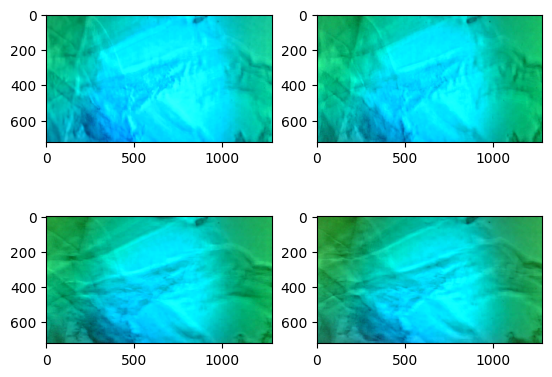

In [8]:
# Visualize the different images 
plt.subplot(221)
plt.imshow(mFrames[0])
plt.subplot(222)
plt.imshow(mFrames[1])
plt.subplot(223)
plt.imshow(mFrames[2])
plt.subplot(224)
plt.imshow(mFrames[3])



# Compute the DPC images

**ATTENTION:** Ensure that the images are TOP/BOTTOM, LEFT/RIGHT illumination, you can adjust the indices mFrames 0..3

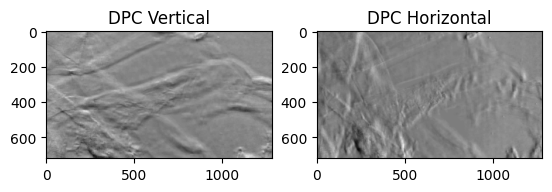

In [36]:
iChannel = 1 # play with this to minimize/maximize crosstalk - against the rules anyway

# extract the colour channel 
dpcLeft = np.float32(mFrames[2][:,:,iChannel])
dpcRight = np.float32(mFrames[3][:,:,iChannel])
dpcTop = np.float32(mFrames[0][:,:,iChannel])
dpcBottom = np.float32(mFrames[1][:,:,iChannel])

dpcVert = (dpcLeft-dpcRight)/(dpcLeft+dpcRight)
dpcHorz = (dpcTop-dpcBottom)/(dpcTop+dpcBottom)

# display

plt.subplot(121)
plt.title("DPC Vertical")
plt.imshow(dpcVert, cmap='gray')
plt.subplot(122)
plt.title("DPC Horizontal")
plt.imshow(dpcHorz,cmap='gray')


# Introduce the qDPC Model

In [37]:
import numpy as np
from scipy.ndimage import uniform_filter
pi    = np.pi
naxis = np.newaxis
F     = lambda x: np.fft.fft2(x)
IF    = lambda x: np.fft.ifft2(x)

def pupilGen(fxlin, fylin, wavelength, na, na_in=0.0):
    pupil = np.array(fxlin[naxis, :]**2+fylin[:, naxis]**2 <= (na/wavelength)**2)
    if na_in != 0.0:
        pupil[fxlin[naxis, :]**2+fylin[:, naxis]**2 < (na_in/wavelength)**2] = 0.0
    return pupil

def _genGrid(size, dx):
    xlin = np.arange(size, dtype='complex128')
    return (xlin-size//2)*dx

class DPCSolver:
    def __init__(self, dpc_imgs, wavelength, na, na_in, pixel_size, rotation, dpc_num=4):
        self.wavelength = wavelength
        self.na         = na
        self.na_in      = na_in
        self.pixel_size = pixel_size
        self.dpc_num    = 4
        self.rotation   = rotation
        self.fxlin      = np.fft.ifftshift(_genGrid(dpc_imgs.shape[-1], 1.0/dpc_imgs.shape[-1]/self.pixel_size))
        self.fylin      = np.fft.ifftshift(_genGrid(dpc_imgs.shape[-2], 1.0/dpc_imgs.shape[-2]/self.pixel_size))
        self.dpc_imgs   = dpc_imgs.astype('float64')
        self.normalization()
        self.pupil      = pupilGen(self.fxlin, self.fylin, self.wavelength, self.na)
        self.sourceGen()
        self.WOTFGen()

    def setTikhonovRegularization(self, reg_u = 1e-6, reg_p = 1e-6):
        self.reg_u      = reg_u
        self.reg_p      = reg_p

    def normalization(self):
        for img in self.dpc_imgs:
            img          /= uniform_filter(img, size=img.shape[0]//2)
            meanIntensity = img.mean()
            img          /= meanIntensity        # normalize intensity with DC term
            img          -= 1.0                  # subtract the DC term

    def sourceGen(self):
        self.source = []
        pupil       = pupilGen(self.fxlin, self.fylin, self.wavelength, self.na, na_in=self.na_in)
        for rotIdx in range(self.dpc_num):
            self.source.append(np.zeros((self.dpc_imgs.shape[-2:])))
            rotdegree = self.rotation[rotIdx]
            if rotdegree < 180:
                self.source[-1][self.fylin[:, naxis]*np.cos(np.deg2rad(rotdegree))+1e-15>=
                                self.fxlin[naxis, :]*np.sin(np.deg2rad(rotdegree))] = 1.0
                self.source[-1] *= pupil
            else:
                self.source[-1][self.fylin[:, naxis]*np.cos(np.deg2rad(rotdegree))+1e-15<
                                self.fxlin[naxis, :]*np.sin(np.deg2rad(rotdegree))] = -1.0
                self.source[-1] *= pupil
                self.source[-1] += pupil
        self.source = np.asarray(self.source)

    def WOTFGen(self):
        self.Hu = []
        self.Hp = []
        for rotIdx in range(self.source.shape[0]):
            FSP_cFP  = F(self.source[rotIdx]*self.pupil)*F(self.pupil).conj()
            I0       = (self.source[rotIdx]*self.pupil*self.pupil.conj()).sum()
            self.Hu.append(2.0*IF(FSP_cFP.real)/I0)
            self.Hp.append(2.0j*IF(1j*FSP_cFP.imag)/I0)
        self.Hu = np.asarray(self.Hu)
        self.Hp = np.asarray(self.Hp)

    def solve(self, xini=None, plot_verbose=False, **kwargs):
        dpc_result  = []
        AHA         = [(self.Hu.conj()*self.Hu).sum(axis=0)+self.reg_u,            (self.Hu.conj()*self.Hp).sum(axis=0),\
                       (self.Hp.conj()*self.Hu).sum(axis=0)           , (self.Hp.conj()*self.Hp).sum(axis=0)+self.reg_p]
        determinant = AHA[0]*AHA[3]-AHA[1]*AHA[2]
        for frame_index in range(self.dpc_imgs.shape[0]//self.dpc_num):
            fIntensity = np.asarray([F(self.dpc_imgs[frame_index*self.dpc_num+image_index]) for image_index in range(self.dpc_num)])
            AHy        = np.asarray([(self.Hu.conj()*fIntensity).sum(axis=0), (self.Hp.conj()*fIntensity).sum(axis=0)])
            absorption = IF((AHA[3]*AHy[0]-AHA[1]*AHy[1])/determinant).real
            phase      = IF((AHA[0]*AHy[1]-AHA[2]*AHy[0])/determinant).real
            dpc_result.append(absorption+1.0j*phase)

        return np.asarray(dpc_result)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from skimage import io
from mpl_toolkits.axes_grid1 import make_axes_locatable


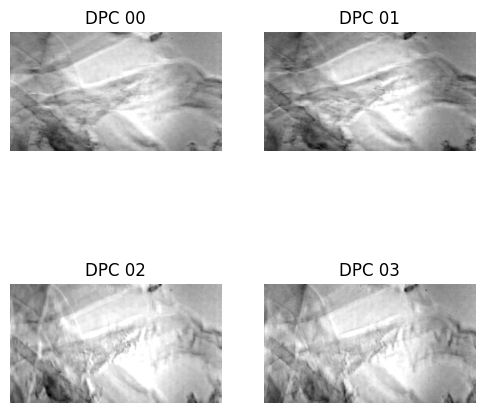

In [39]:

dpc_images = np.array((dpcLeft, dpcRight, dpcTop, dpcBottom))


#plot first set of measured DPC measurements
f, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 6))

for plot_index in range(4):
    plot_row = plot_index//2
    plot_col = np.mod(plot_index, 2)
    ax[plot_row, plot_col].imshow(dpc_images[plot_index], cmap="gray")
    ax[plot_row, plot_col].axis("off")
    ax[plot_row, plot_col].set_title("DPC {:02d}".format(plot_index))
plt.show()


In [40]:
wavelength     =  0.514 #micron
mag            =   40.0
na             =   0.40 #numerical aperture
na_in          =    0.0
pixel_size_cam =    6.5 #pixel size of camera
dpc_num        =      4 #number of DPC images captured for each absorption and phase frame
pixel_size     = pixel_size_cam/mag
rotation       = [0, 180, 90, 270] #degree

In [41]:
# Initialize DPC Solver
dpc_solver_obj = DPCSolver(dpc_images, wavelength, na, na_in, pixel_size, rotation, dpc_num=dpc_num)

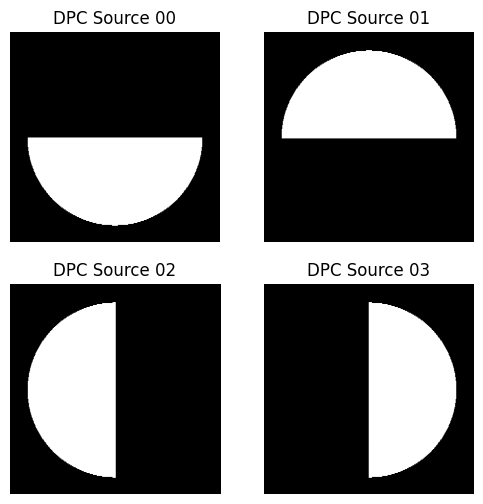

In [42]:
#plot the sources
max_na_x = max(dpc_solver_obj.fxlin.real*dpc_solver_obj.wavelength/dpc_solver_obj.na)
min_na_x = min(dpc_solver_obj.fxlin.real*dpc_solver_obj.wavelength/dpc_solver_obj.na)
max_na_y = max(dpc_solver_obj.fylin.real*dpc_solver_obj.wavelength/dpc_solver_obj.na)
min_na_y = min(dpc_solver_obj.fylin.real*dpc_solver_obj.wavelength/dpc_solver_obj.na)
f, ax  = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 6))
for plot_index, source in enumerate(list(dpc_solver_obj.source)):
    plot_row = plot_index//2
    plot_col = np.mod(plot_index, 2)
    ax[plot_row, plot_col].imshow(np.fft.fftshift(dpc_solver_obj.source[plot_index]),\
                                  cmap='gray', clim=(0,1), extent=[min_na_x, max_na_x, min_na_y, max_na_y])
    ax[plot_row, plot_col].axis("off")
    ax[plot_row, plot_col].set_title("DPC Source {:02d}".format(plot_index))
    ax[plot_row, plot_col].set_xlim(-1.2, 1.2)
    ax[plot_row, plot_col].set_ylim(-1.2, 1.2)
    ax[plot_row, plot_col].set_aspect(1)

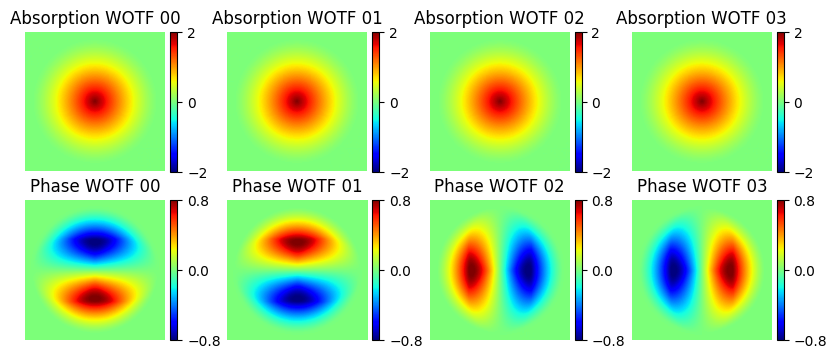

In [43]:
# Visualize the Weak object transfer function (WOTF)

#plot the transfer functions
f, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize = (10, 4))
for plot_index in range(ax.size):
    plot_row = plot_index//4
    plot_col = np.mod(plot_index, 4)
    divider  = make_axes_locatable(ax[plot_row, plot_col])
    cax      = divider.append_axes("right", size="5%", pad=0.05)
    if plot_row == 0:
        plot = ax[plot_row, plot_col].imshow(np.fft.fftshift(dpc_solver_obj.Hu[plot_col].real), cmap='jet',\
                                             extent=[min_na_x, max_na_x, min_na_y, max_na_y], clim=[-2., 2.])
        ax[plot_row, plot_col].set_title("Absorption WOTF {:02d}".format(plot_col))
        plt.colorbar(plot, cax=cax, ticks=[-2., 0, 2.])
    else:
        plot = ax[plot_row, plot_col].imshow(np.fft.fftshift(dpc_solver_obj.Hp[plot_col].imag), cmap='jet',\
                                             extent=[min_na_x, max_na_x, min_na_y, max_na_y], clim=[-.8, .8])
        ax[plot_row, plot_col].set_title("Phase WOTF {:02d}".format(plot_col))
        plt.colorbar(plot, cax=cax, ticks=[-.8, 0, .8])
    ax[plot_row, plot_col].set_xlim(-2.2, 2.2)
    ax[plot_row, plot_col].set_ylim(-2.2, 2.2)
    ax[plot_row, plot_col].axis("off")
    ax[plot_row, plot_col].set_aspect(1)

In [44]:
#parameters for Tikhonov regurlarization [absorption, phase] ((need to tune this based on SNR)
dpc_solver_obj.setTikhonovRegularization(reg_u = 1e-1, reg_p = 5e-3)
dpc_result = dpc_solver_obj.solve()

Text(0.5, 1.0, 'Phase')

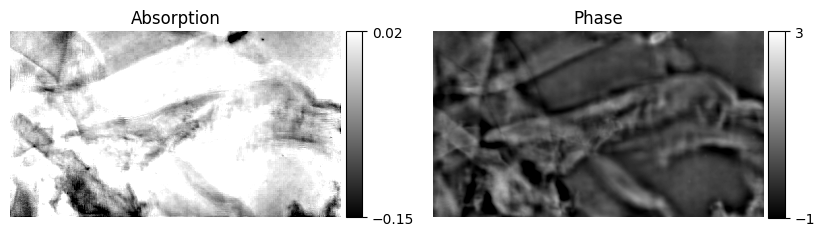

In [45]:
_, axes  = plt.subplots(1, 2, figsize=(10, 6), sharex=True, sharey=True)
divider  = make_axes_locatable(axes[0])
cax_1    = divider.append_axes("right", size="5%", pad=0.05)
plot     = axes[0].imshow(dpc_result[0].real, clim=[-0.15, 0.02], cmap="gray", extent=[0, dpc_result[0].shape[-1], 0, dpc_result[0].shape[-2]])
axes[0].axis("off")
plt.colorbar(plot, cax=cax_1, ticks=[-0.15, 0.02])
axes[0].set_title("Absorption")
divider  = make_axes_locatable(axes[1])
cax_2    = divider.append_axes("right", size="5%", pad=0.05)
plot     = axes[1].imshow(dpc_result[0].imag, clim=[-1.0, 3.0], cmap="gray", extent=[0, dpc_result[0].shape[-1], 0, dpc_result[0].shape[-2]])
axes[1].axis("off")
plt.colorbar(plot, cax=cax_2, ticks=[-1.0, 3.0])
axes[1].set_title("Phase")